In [ ]:
#brain maps - apply pca to stacked up (1.8 million, 500 object to get it down to 500 by 500), then apply t-sne to get it down to (2, 500 PCs)
# apply delauney triangulation to get shape

In [2]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import scipy as sp
import scipy.special
from sklearn import manifold
import pickle

import sys
sys.path.insert(0, '/jukebox/hasson/snastase/social-ctf')
from ctf_dataset import load
from ctf_dataset import info
from ctf_dataset.info import constants
from ctf_dataset.info import events
from ctf_dataset.load import virtual
from ctf_dataset.load import utils as load_utils
import time

In [3]:
n_maps = 32
n_repeats = 32
n_players = 4
n_samples = 4501
n_pcs = 512

n_total = n_maps * n_repeats * n_players * n_samples

In [4]:
lstms_pca_maps = np.memmap(f'/jukebox/hasson/snastase/social-ctf/results/lstms-stack_tanh-z_pca-proj_matchup-0.npy', mode='r', dtype='float64', shape = (n_total, 512))
lstms_pca_maps = np.transpose(lstms_pca_maps)

In [5]:
lstms_pca_maps.shape

(512, 18436096)

In [6]:
from scipy.stats import zscore
lstms_pca_maps_z = np.memmap('results/Brain_Map_stack_z.npy', dtype='float64', mode='w+', shape=lstms_pca_maps.shape)
lstms_pca_maps_z[:] = zscore(lstms_pca_maps, axis=1)

In [7]:
lstms_pca_maps_z

memmap([[-0.74929147, -1.72124927, -1.47072637, ..., -0.2755646 ,
         -0.26096511, -0.25042902],
        [-0.67297044, -0.76940852, -0.75717257, ..., -1.67024818,
         -1.73206037, -1.77363051],
        [ 0.66401208,  0.86814015,  1.3370147 , ...,  0.61719281,
          0.71048154,  0.76185728],
        ...,
        [-1.10391847, -0.56630457, -0.51962563, ...,  1.70054742,
          2.30391767,  2.48370198],
        [ 0.13539052,  1.49685316, -0.22037434, ..., -1.48330538,
         -3.13702182, -3.70708456],
        [-3.09514207, -2.24545982,  1.30735479, ..., -0.25492739,
          1.44851688,  1.93248942]])

In [8]:
np.mean(lstms_pca_maps_z[:,:3],axis=0)

array([-0.0585756 , -0.20960205,  0.05577297])

In [9]:
pca

NameError: name 'pca' is not defined

In [ ]:
from sklearn.decomposition import PCA
k = 142 # set this to 142
pca = PCA(n_components = k,svd_solver = 'randomized')
reduced = pca.fit_transform(lstms_pca_maps)

In [ ]:
reduced.shape

In [ ]:
np.sum(pca.explained_variance_ratio_)

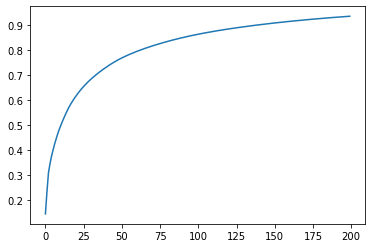

In [26]:
plt.plot(np.cumsum(pca.explained_variance_ratio_))

In [40]:
np.sum(np.cumsum(pca.explained_variance_ratio_) < .9) +1

141

In [9]:
np.save('results/BrainMaps_PCA_200.npy',reduced) # save pca also!!

array([[ 3.67252202e+04,  8.66597287e+01,  6.03300752e+01, ...,
        -1.53749087e-02,  1.63348963e-02,  2.05710895e-02],
       [-1.83694479e+02,  2.87655995e+04,  3.55617092e+02, ...,
        -2.51084384e-02,  2.66743175e-02,  3.35888976e-02],
       [-1.52745872e+02, -4.37704965e+02,  2.68763954e+04, ...,
        -2.87819639e-02,  3.05761392e-02,  3.85008699e-02],
       ...,
       [-7.07814201e+01, -5.48652267e+01, -5.25356622e+01, ...,
         5.15907456e+00, -5.91824420e+00, -7.41661611e+00],
       [-7.07794491e+01, -5.48627365e+01, -5.25329307e+01, ...,
         5.11524401e+00, -5.85779263e+00, -7.34571384e+00],
       [-7.07775694e+01, -5.48603618e+01, -5.25303259e+01, ...,
         5.06923947e+00, -5.79360186e+00, -7.28001739e+00]])

In [38]:
reduced = np.load('results/BrainMaps_PCA_200.npy')

In [39]:
reduced.shape

(512, 200)

In [5]:
import pickle
with open('results/BrainMaps_PCA_200.pkl','wb') as f: 
    pickle.dump(pca, f)

In [6]:
lstms_pca_maps_z = np.memmap('results/Brain_Map_stack_z.npy',dtype='float64',mode='w+',shape=lstms_pca_maps.shape)

NameError: name 'lstms_pca_maps' is not defined

In [126]:
reduced_z.shape

(512, 142)

In [ ]:
from scipy.stats import zscore
reduced_z = zscore(reduced[:,:142],axis=0)

In [ ]:
# try with 8 
def get_tsne_embedding_parallel(filtered_pcs, n_components=2, perplexity = 350, random_state=0,n_jobs=24,learning_rate = 'auto'):
    embedding = manifold.TSNE(n_components, perplexity = perplexity, random_state=random_state,n_jobs=n_jobs)
    filtered_pcs_tsne = embedding.fit_transform(filtered_pcs)
    return filtered_pcs_tsne, embedding

In [ ]:
filtered_pcs_tsne, embedding = get_tsne_embedding_parallel(reduced[:,:142], n_components=2)

In [ ]:
filtered_pcs_tsne_z, embedding_z = get_tsne_embedding_parallel(reduced_z, n_components=2)

In [1]:
filtered_pcs_tsne.shape

NameError: name 'filtered_pcs_tsne' is not defined

In [3]:
np.save('results/BrainMaps_PCA_200_tsne.npy',filtered_pcs_tsne)

NameError: name 'filtered_pcs_tsne' is not defined

In [ ]:
with open('results/BrainMaps_PCA_200_tsne.pkl','wb') as f: 
    pickle.dump(embedding, f)

In [81]:
np.save('results/BrainMaps_PCA_200_tsne_z.npy',filtered_pcs_tsne_z)
with open('results/BrainMaps_PCA_200_tsne_z.pkl','wb') as f: 
    pickle.dump(embedding_z, f)

In [ ]:
tri_scipy = sp.spatial.Delaunay(filtered_pcs_tsne_z)

In [ ]:
plt.scatter(filtered_pcs_tsne_z[:, 0], filtered_pcs_tsne_z[:, 1])

In [ ]:
tri_scipy_z = sp.spatial.Delaunay(filtered_pcs_tsne_z)
plt.scatter(filtered_pcs_tsne_z[:, 0], filtered_pcs_tsne_z[:, 1])

In [110]:
tri_scipy.simplices.shape

(1007, 3)

In [111]:
centers = np.sum(filtered_pcs_tsne[tri_scipy.simplices], axis=1, dtype='float64')/3.0

In [112]:
centers.shape

(1007, 2)

In [113]:
h = 300
w = 1000


colors = np.array([ (x-w/2.)**2 + (y-h/2.)**2 for x,y in centers])

In [114]:
colors.shape

(1007,)

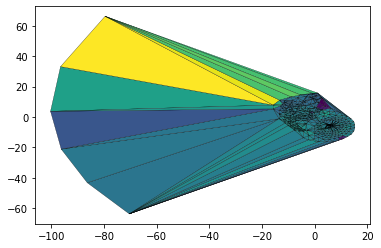

In [115]:

plt.tripcolor(filtered_pcs_tsne_z[:,0], filtered_pcs_tsne_z[:,1], tri_scipy.simplices.copy(), facecolors=colors, edgecolors='k')


In [64]:

plt.tripcolor(filtered_pcs_tsne_z[:,0], filtered_pcs_tsne_z[:,1], tri_scipy_z.simplices.copy(), facecolors=colors, edgecolors='k')



NameError: name 'filtered_pcs_tsne_z' is not defined

In [108]:
A = np.random.rand(512,)

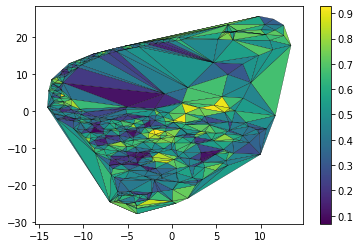

In [109]:
fig, ax = plt.subplots()
tpc = ax.tripcolor(filtered_pcs_tsne[:,0], filtered_pcs_tsne[:,1], tri_scipy.simplices.copy(), A, edgecolors='k')
fig.colorbar(tpc)

In [ ]:
# Data directory.
DATA_DIR = "/jukebox/hasson/snastase/social-ctf/data_v1" 
# Create Wrapped dataset.
wrap_file = load.create_wrapped_dataset(DATA_DIR, output_dataset_name="virtual.hdf5")

In [ ]:
def filter_dataset(
    which_maps, wrap_file, value_name,
    map_id=slice(None), matchup_id=slice(None), repeat_id=slice(None),
    player_id=slice(None), time=slice(None, None, 500),melt=True):
    """Slices and filters data."""
    # Good time factors are:
    # 2250, 1500, 1125, 900, 750, 500, 450, 375, 300, 250, 225, 180, 150, 125, 100.
    # These will always include the first and last lstm state. 

    # ** why is time factor default 500 here here?

    # Slice the data.
    value = wrap_file["map/matchup/repeat/player/time/{}".format(value_name)][map_id, matchup_id, repeat_id, player_id, time, ...]

    # Filter on agent id.
    value_shape = (value.shape[-1],)

    # Convert last.
    value = value.astype(np.float32)
    
    if melt:
        value = np.reshape(value, (-1,) + value_shape)

        
    map_size = 576128  
    full_array = np.zeros((map_size*len(which_maps),value.shape[1]))
    count = 0
    for map in which_maps:
        full_array[(map_size*count):(map_size*(count+1)),:] = value[(map_size*map):(map_size*(map+1)),:]
        count += 1
        
        
    return full_array

# filtered_ts = filter_dataset(np.arange(2),wrap_file, value_name="action", **filter_kwargs_tsne)

In [ ]:
filter_kwargs_tsne = dict(
    map_id=slice(None),
    matchup_id=0,
    repeat_id=slice(None),
    player_id=slice(None),
    time=slice(None),
    melt = True
)

In [24]:
filtered_pcs_tsne = np.load('results/BrainMaps_PCA_200_tsne.npy')

In [ ]:
health = filter_dataset(np.arange(32),wrap_file, value_name="health", **filter_kwargs_tsne)
health *= 200

In [131]:
alive = health>0
alive[:,0].shape

(18436096,)

In [125]:
lstms_pca_maps_z.shape

(512, 18436096)

In [22]:
activity = np.mean(lstms_pca_maps_z[:,alive[:,0]],axis=1) - np.mean(lstms_pca_maps_z[:,~alive[:,0]],axis=1)

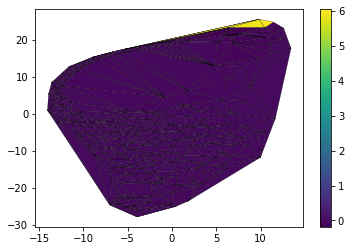

In [26]:
fig, ax = plt.subplots()
tpc = ax.tripcolor(filtered_pcs_tsne[:,0], filtered_pcs_tsne[:,1], tri_scipy.simplices.copy(), activity, edgecolors='k')
fig.colorbar(tpc)

In [32]:
scaled_activity.shape

(512, 1)

In [42]:
scaled_activity = ((activity - np.min(activity))*(1 - -1)/(np.max(activity) - np.min(activity))) + -1

In [55]:
[np.min(scaled_activity),np.max(scaled_activity)]

[-1.0, 1.0]

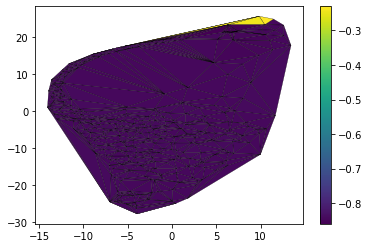

In [46]:
fig, ax = plt.subplots()
tpc = ax.tripcolor(filtered_pcs_tsne[:,0], filtered_pcs_tsne[:,1], tri_scipy.simplices.copy(), scaled_activity, edgecolors='k')
fig.colorbar(tpc)

In [ ]:
cb.set_ticks([0, 1, 2, 3, 4, 5, 6, 7, 8])
    cb.set_ticklabels([
      "Own Home, Other Home",
      "Own Home, Other Carried",
      "Own Home, Other Dropped",
      "Own Carried, Other Home",
      "Own Carried, Other Carried",
      "Own Carried, Other Dropped",
      "Own Dropped, Other Home",
      "Own Dropped, Other Carried",
      "Own Dropped, Other Dropped",
    ])
    cb.set_label("Game State")

In [57]:
status = filter_dataset(np.arange(32),wrap_file, value_name="own_game_status", **filter_kwargs_tsne)

In [59]:
status_own_home_other_carried = status == 1
print(status_own_home_other_carried.shape)
activity_own_home_other_carried = np.mean(lstms_pca_maps_z[:,status_own_home_other_carried[:,0]],axis=1) - np.mean(lstms_pca_maps_z[:,~status_own_home_other_carried[:,0]],axis=1)
scaled_activity_own_home_other_carried = ((activity_own_home_other_carried - np.min(activity_own_home_other_carried))*(1 - -1)/(np.max(activity_own_home_other_carried) - np.min(activity_own_home_other_carried))) + -1
print([np.min(scaled_activity_own_home_other_carried),np.max(scaled_activity_own_home_other_carried)])

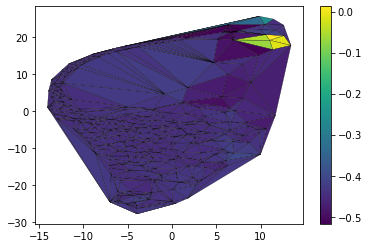

In [66]:
fig, ax = plt.subplots()

tpc = ax.tripcolor(filtered_pcs_tsne[:,0], filtered_pcs_tsne[:,1], tri_scipy.simplices.copy(), scaled_activity_own_home_other_carried, edgecolors='k')
fig.colorbar(tpc)

In [69]:
status_own_carried_other_carried = status == 4
print(status_own_carried_other_carried.shape)
activity_own_carried_other_carried = np.mean(lstms_pca_maps_z[:,status_own_carried_other_carried[:,0]],axis=1) - np.mean(lstms_pca_maps_z[:,~status_own_carried_other_carried[:,0]],axis=1)
scaled_activity_own_carried_other_carried = ((activity_own_carried_other_carried - np.min(activity_own_carried_other_carried))*(1 - -1)/(np.max(activity_own_carried_other_carried) - np.min(activity_own_carried_other_carried))) + -1
print([np.min(scaled_activity_own_carried_other_carried),np.max(scaled_activity_own_carried_other_carried)])

(18436096, 1)
[-1.0, 1.0]


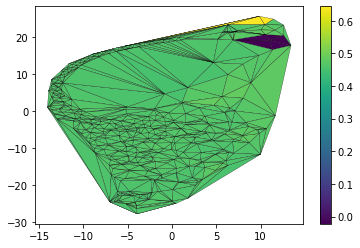

In [70]:
fig, ax = plt.subplots()

tpc = ax.tripcolor(filtered_pcs_tsne[:,0], filtered_pcs_tsne[:,1], tri_scipy.simplices.copy(), scaled_activity_own_carried_other_carried, edgecolors='k')
fig.colorbar(tpc)